In [4]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, make_interp_spline
import numpy as np
from pathlib import Path
sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size



# Analyse CFU data from community assembly 2

## Read in data

In [5]:
data_folder = Path("../../data/3_second_community_assembly")
file_to_open = data_folder / "cfus.csv"
df = pd.read_csv(file_to_open, index_col=0)

In [6]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [7]:
strains = ['At', 'Ct', 'Ml', 'Oa']

## Rename carbons sources for simplification

In [8]:
df['Carbon source'] = df['Carbon source'].str.replace('L-', '').str.replace('D-','')
df['Carbon source'] = df['Carbon source'].str.replace('0.0', ' 0.0').str.replace('5',' 5').str.replace('+vits', ' + AA & vitamins')
df.sort_values(by = 'Carbon source', inplace=True)
carbon_sources = df['Carbon source'].unique()
rich_and_control = ['LB', 'TSB', 'Vits control', 'No CS']
carbon_sources = [x for x in carbon_sources if isinstance(x, str) and x not in rich_and_control] + rich_and_control
print(carbon_sources)

['Acetate', 'Acetate + AA & vitamins', 'Acetate 0.02x', 'Acetate 5x', 'Glutamate', 'Glutamate + AA & vitamins', 'Glutamate 0.02x', 'Glutamate 5x', 'Glutarate', 'Glutarate + AA & vitamins', 'Glutarate 0.02x', 'Glutarate 5x', 'Histidine', 'Histidine + AA & vitamins', 'Histidine 0.02x', 'Histidine 5x', 'Inosine', 'Inosine + AA & vitamins', 'Inosine 0.02x', 'Inosine 5x', 'Malate', 'Malate + AA & vitamins', 'Malate 0.02x', 'Malate 5x', 'Ribose', 'Ribose + AA & vitamins', 'Ribose 0.02x', 'Ribose 5x', 'LB', 'TSB', 'Vits control', 'No CS']


# Plot CFUs

## Version one - only scatterpoints
First only with and without vitamins

In [9]:
carbon_sources_vits_only = [x for x in carbon_sources if not 'x' in str(x)]
carbon_sources_vits_only = [x for x in carbon_sources_vits_only if not x in rich_and_control]
carbon_sources_vits_only

['Acetate',
 'Acetate + AA & vitamins',
 'Glutamate',
 'Glutamate + AA & vitamins',
 'Glutarate',
 'Glutarate + AA & vitamins',
 'Histidine',
 'Histidine + AA & vitamins',
 'Inosine',
 'Inosine + AA & vitamins',
 'Malate',
 'Malate + AA & vitamins',
 'Ribose',
 'Ribose + AA & vitamins']

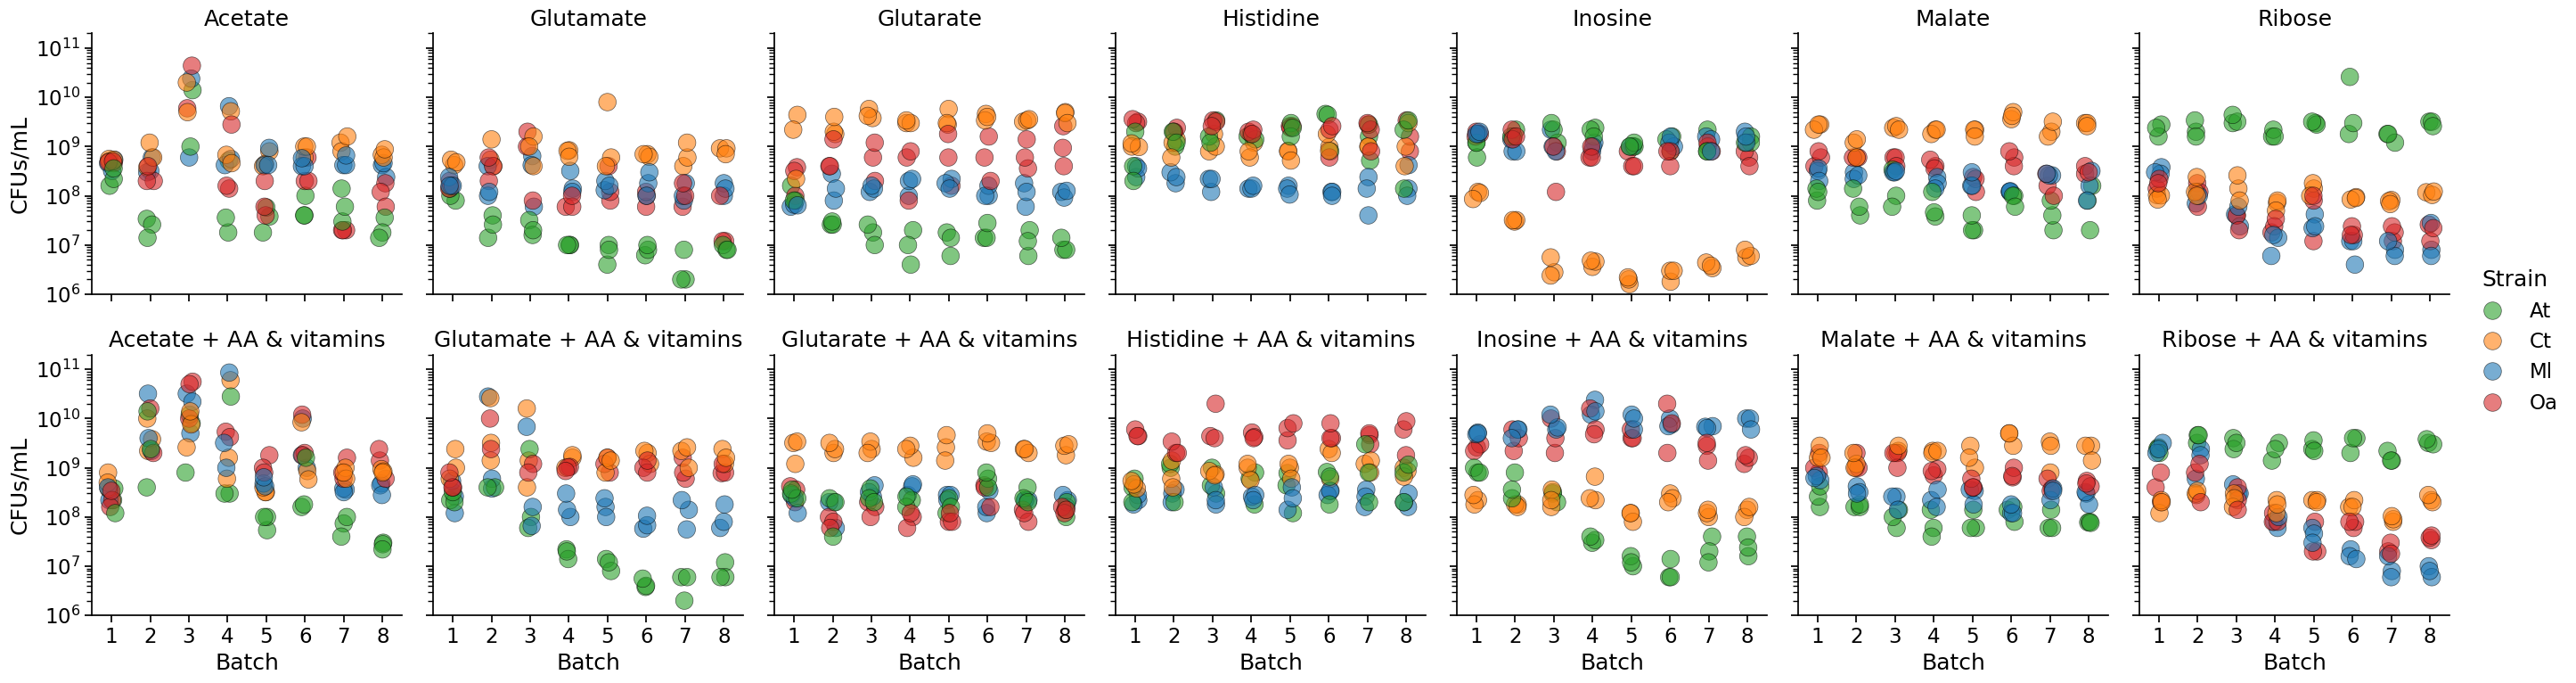

In [10]:
col_order = carbon_sources_vits_only[::2]+carbon_sources_vits_only[1::2]
ncols = 7
# Create the catplot
idx = df['Carbon source'].isin(carbon_sources_vits_only)
g = sns.catplot(
    data=df.loc[idx],
    x='Batch',
    y='CFUs/mL',
    hue='Strain',
    col='Carbon source',
    col_wrap=ncols,
    col_order=col_order,
    log_scale=True,
    sharey=True,
    kind='strip',
    palette=palette,
    hue_order=['At', 'Ct', 'Ml', 'Oa'],
    s=200,
    alpha=0.6,
    sharex=True,
    height=4,
    edgecolor='k',
    linewidth=0.5
)
plt.ylim(1e6, 2e11)
# Set titles without "Carbon source = "
g.set_titles("{col_name}")
# g = sns.catplot(data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain', col = 'Carbon source', col_wrap=4, log_scale = True, sharey=True, kind = 'strip', palette = palette, 
#                 hue_order=['At', 'Ct', 'Ml', 'Oa'], s = 200, alpha = 0.5, sharex=True, height = 4, edgecolor = 'k', linewidth = 0.5)

# # g.map_dataframe(sns.lineplot, data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain',  hue_order=['At', 'Ct', 'Ml', 'Oa'], palette = palette, errorbar = None)
# g.set_titles("{col_name}")
plt.savefig(f'../../Figures/coexistence_with_wo_vits_v1.pdf')
plt.show()


# Plot with more or less carbon

In [11]:
cs_more_or_less = [x for x in carbon_sources if not '&' in x and x not in rich_and_control]
cs_more_or_less

['Acetate',
 'Acetate 0.02x',
 'Acetate 5x',
 'Glutamate',
 'Glutamate 0.02x',
 'Glutamate 5x',
 'Glutarate',
 'Glutarate 0.02x',
 'Glutarate 5x',
 'Histidine',
 'Histidine 0.02x',
 'Histidine 5x',
 'Inosine',
 'Inosine 0.02x',
 'Inosine 5x',
 'Malate',
 'Malate 0.02x',
 'Malate 5x',
 'Ribose',
 'Ribose 0.02x',
 'Ribose 5x']

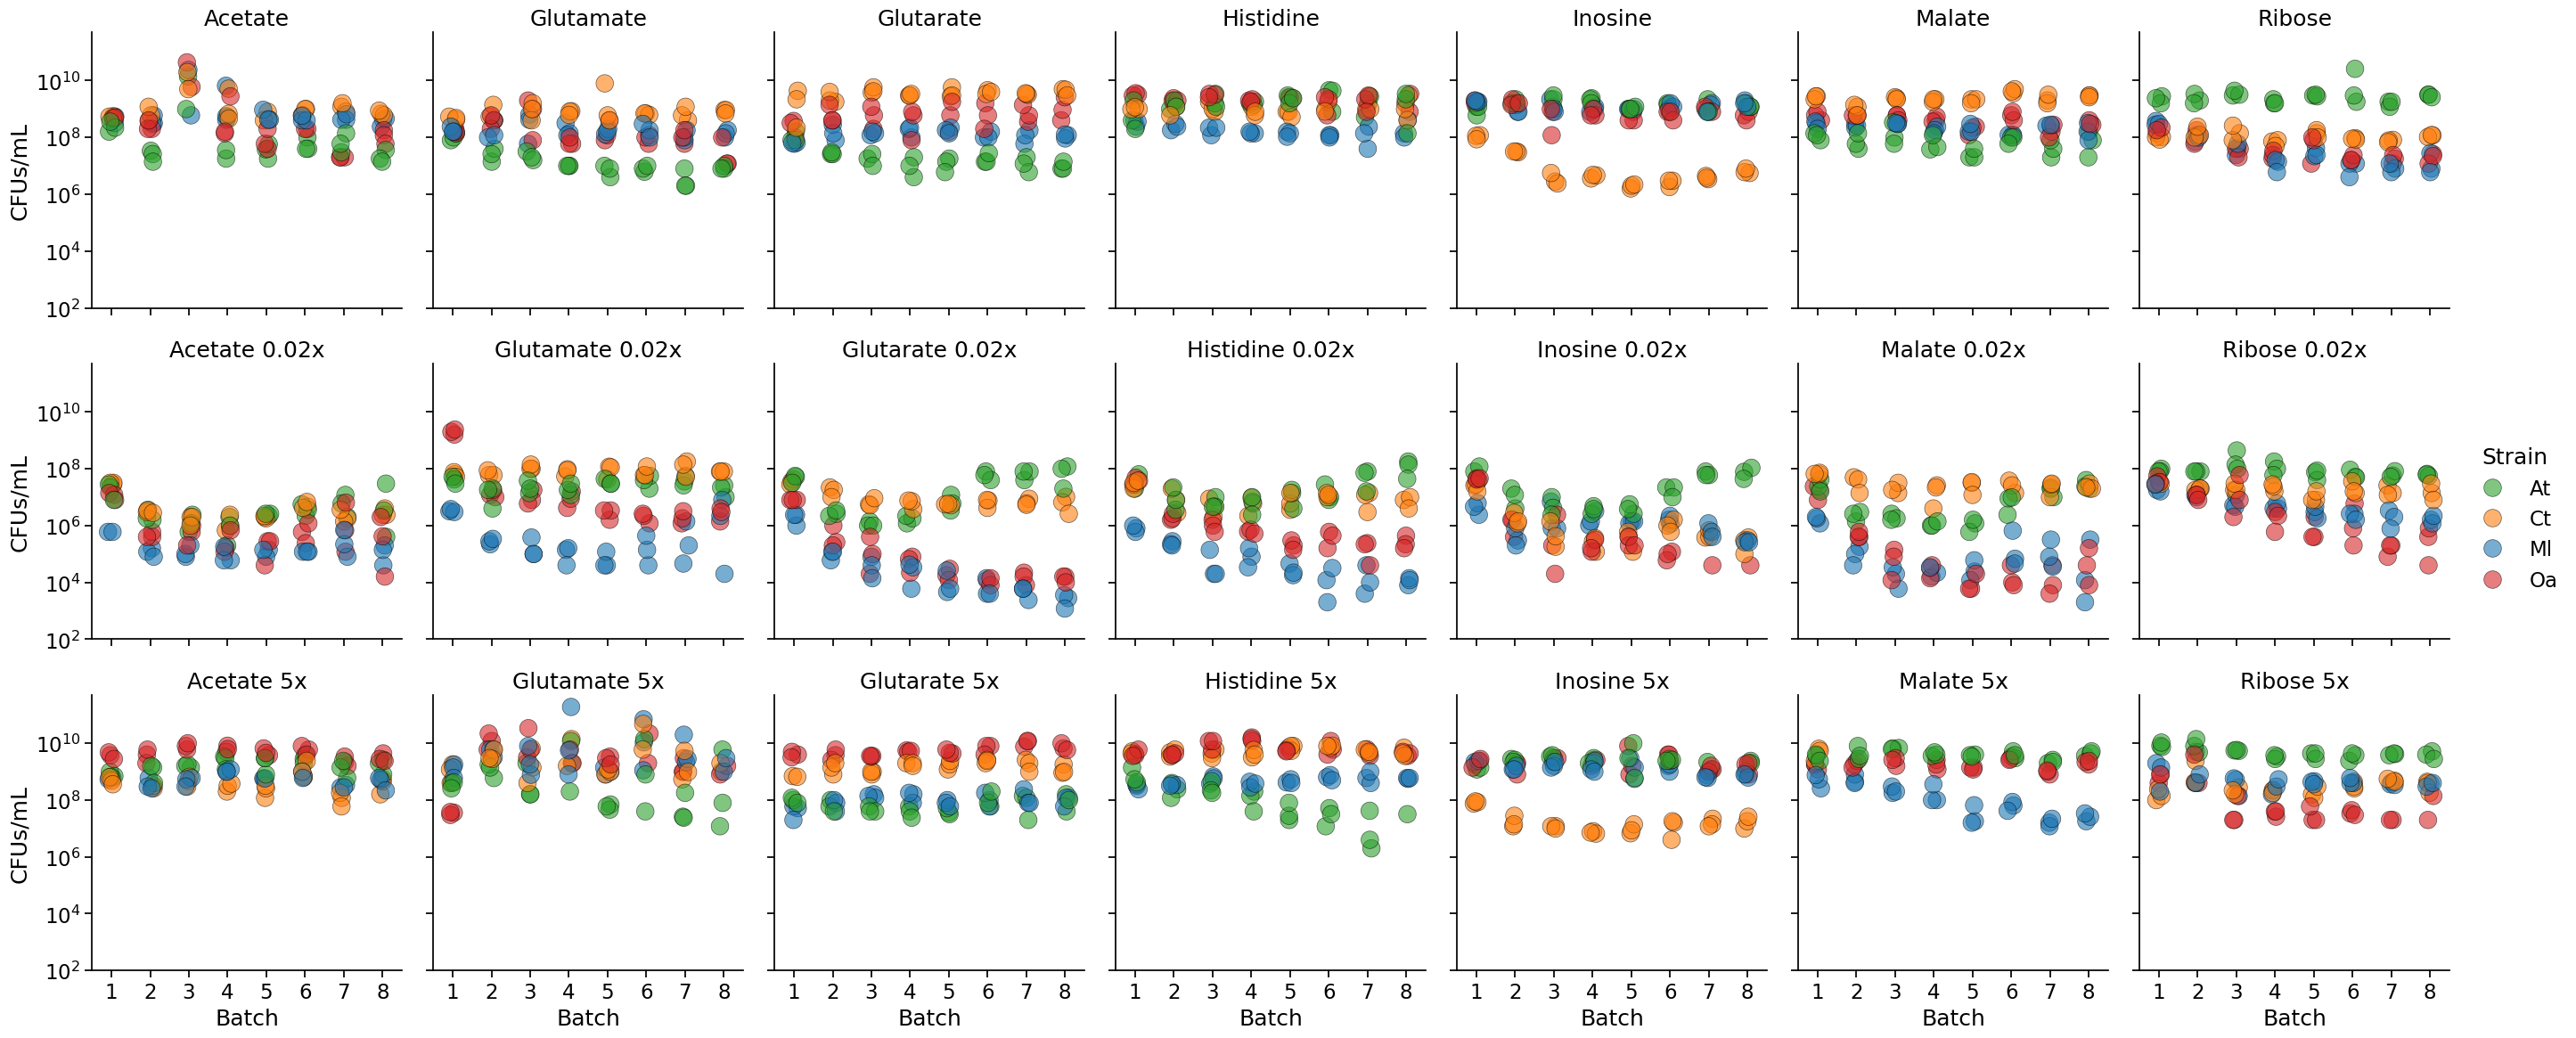

In [12]:
col_order = cs_more_or_less[::3]+cs_more_or_less[1::3]+cs_more_or_less[2::3]
ncols = 7
# Create the catplot
idx = df['Carbon source'].isin(cs_more_or_less)
g = sns.catplot(
    data=df.loc[idx],
    x='Batch',
    y='CFUs/mL',
    hue='Strain',
    col='Carbon source',
    col_wrap=ncols,
    col_order=col_order,
    log_scale=True,
    sharey=True,
    kind='strip',
    palette=palette,
    hue_order=['At', 'Ct', 'Ml', 'Oa'],
    s=200,
    alpha=0.6,
    sharex=True,
    height=4,
    edgecolor='k',
    linewidth=0.5
)
plt.ylim(1e2, 5e11)
# Set titles without "Carbon source = "
g.set_titles("{col_name}")
# g = sns.catplot(data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain', col = 'Carbon source', col_wrap=4, log_scale = True, sharey=True, kind = 'strip', palette = palette, 
#                 hue_order=['At', 'Ct', 'Ml', 'Oa'], s = 200, alpha = 0.5, sharex=True, height = 4, edgecolor = 'k', linewidth = 0.5)

# # g.map_dataframe(sns.lineplot, data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain',  hue_order=['At', 'Ct', 'Ml', 'Oa'], palette = palette, errorbar = None)
# g.set_titles("{col_name}")
plt.savefig(f'../../Figures/coexistence_more_or_less_c_v1.pdf')
plt.show()


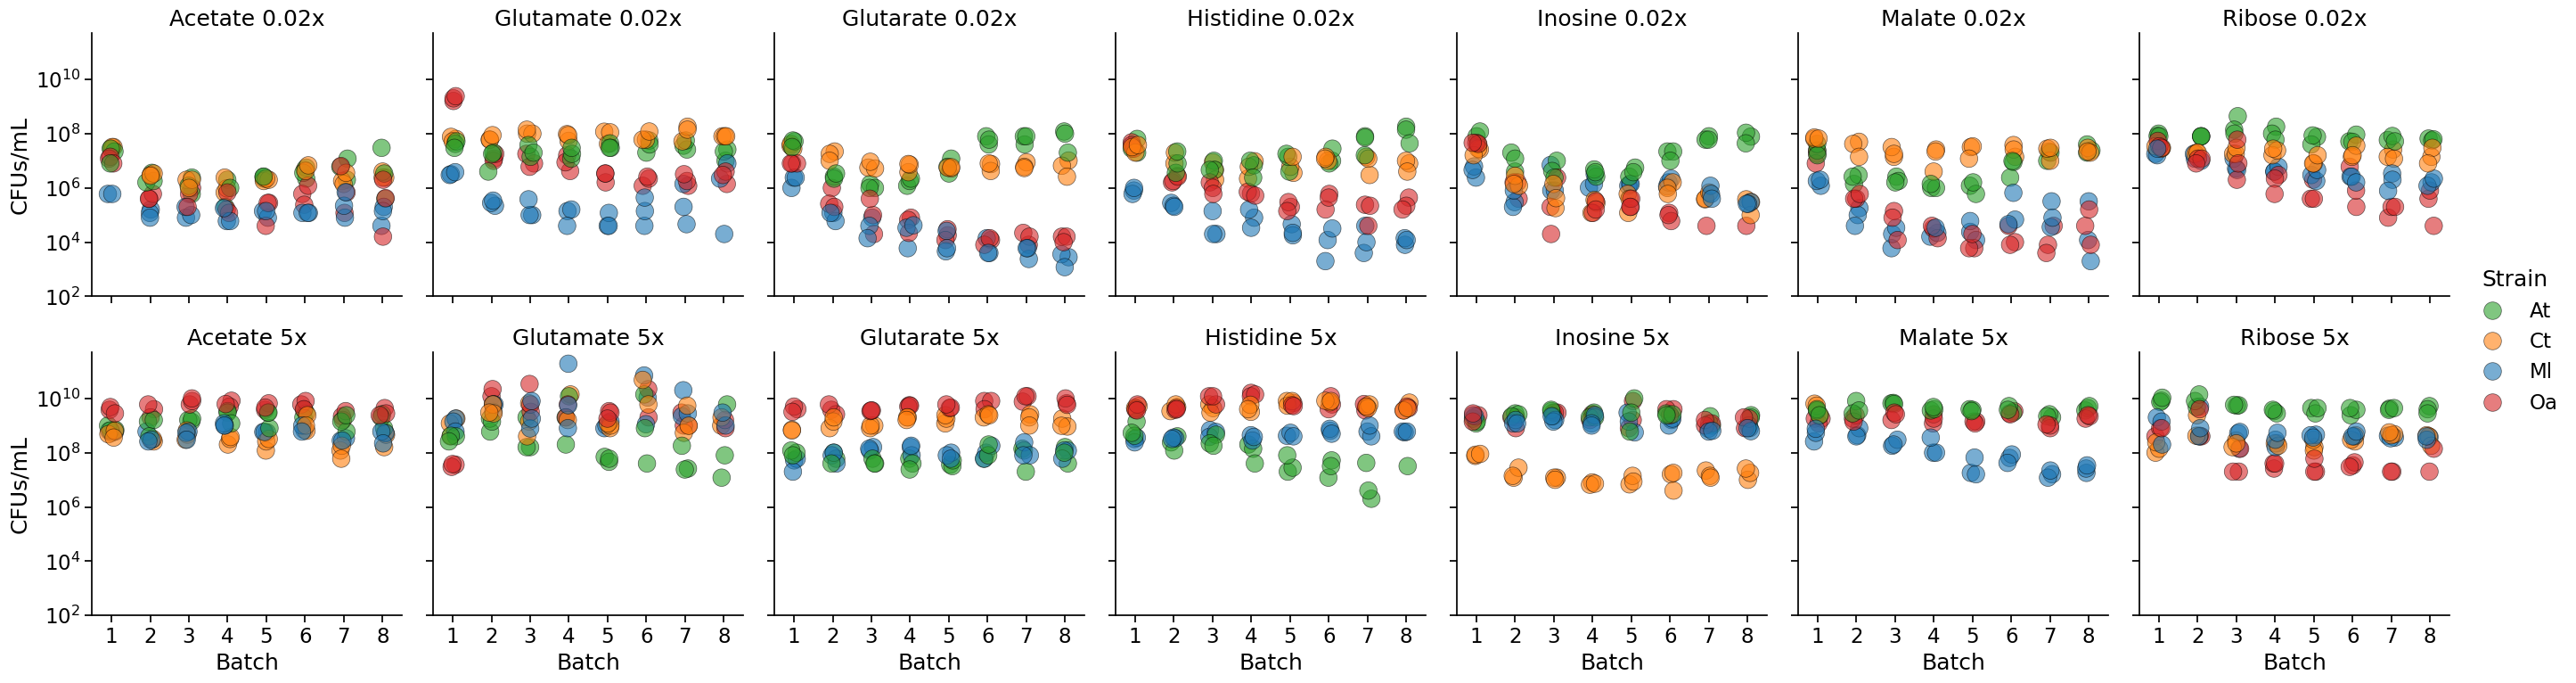

In [13]:
col_order = cs_more_or_less[1::3]+cs_more_or_less[2::3]
ncols = 7
# Create the catplot
idx = df['Carbon source'].isin(cs_more_or_less)
g = sns.catplot(
    data=df.loc[idx],
    x='Batch',
    y='CFUs/mL',
    hue='Strain',
    col='Carbon source',
    col_wrap=ncols,
    col_order=col_order,
    log_scale=True,
    sharey=True,
    kind='strip',
    palette=palette,
    hue_order=['At', 'Ct', 'Ml', 'Oa'],
    s=200,
    alpha=0.6,
    sharex=True,
    height=4,
    edgecolor='k',
    linewidth=0.5
)
plt.ylim(1e2, 5e11)
# Set titles without "Carbon source = "
g.set_titles("{col_name}")
# g = sns.catplot(data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain', col = 'Carbon source', col_wrap=4, log_scale = True, sharey=True, kind = 'strip', palette = palette, 
#                 hue_order=['At', 'Ct', 'Ml', 'Oa'], s = 200, alpha = 0.5, sharex=True, height = 4, edgecolor = 'k', linewidth = 0.5)

# # g.map_dataframe(sns.lineplot, data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain',  hue_order=['At', 'Ct', 'Ml', 'Oa'], palette = palette, errorbar = None)
# g.set_titles("{col_name}")
plt.savefig(f'../../Figures/coexistence_more_or_less_c_v1_no_ref.pdf')
plt.show()


# Plot rich and control

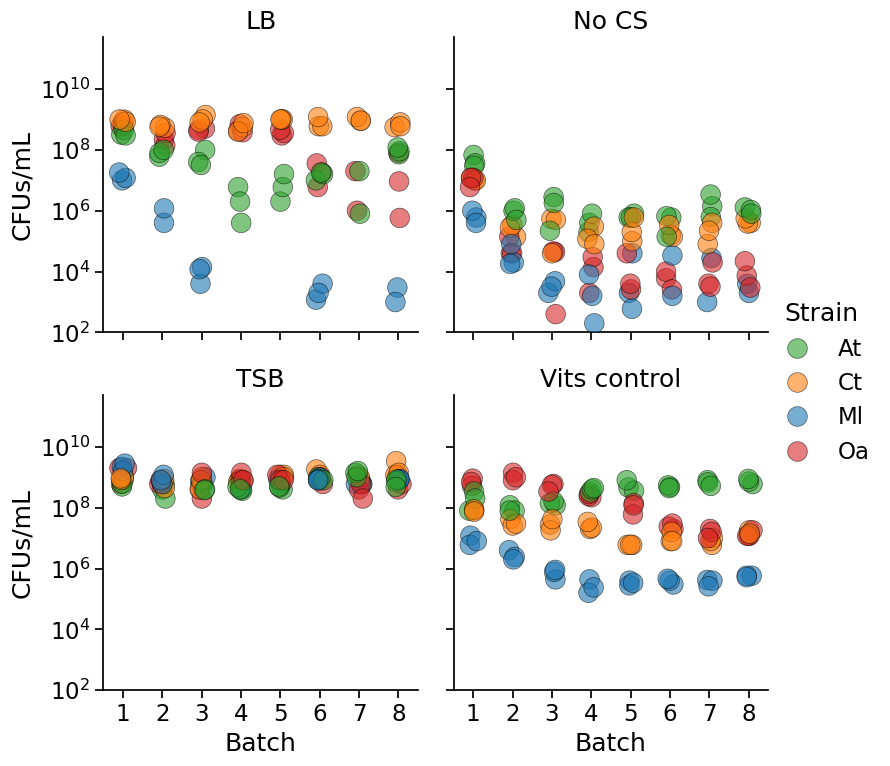

In [15]:
# col_order = cs_more_or_less[1::3]+cs_more_or_less[2::3]
ncols = 2
# Create the catplot
idx = df['Carbon source'].isin(rich_and_control)
g = sns.catplot(
    data=df.loc[idx],
    x='Batch',
    y='CFUs/mL',
    hue='Strain',
    col='Carbon source',
    col_wrap=ncols,
    # col_order=col_order,
    log_scale=True,
    sharey=True,
    kind='strip',
    palette=palette,
    hue_order=['At', 'Ct', 'Ml', 'Oa'],
    s=200,
    alpha=0.6,
    sharex=True,
    height=4,
    edgecolor='k',
    linewidth=0.5
)
plt.ylim(1e2, 5e11)
# Set titles without "Carbon source = "
g.set_titles("{col_name}")
# g = sns.catplot(data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain', col = 'Carbon source', col_wrap=4, log_scale = True, sharey=True, kind = 'strip', palette = palette, 
#                 hue_order=['At', 'Ct', 'Ml', 'Oa'], s = 200, alpha = 0.5, sharex=True, height = 4, edgecolor = 'k', linewidth = 0.5)

# # g.map_dataframe(sns.lineplot, data = df.loc[(df.Batch!=0)], x = 'Batch', y = 'CFUs/mL', hue = 'Strain',  hue_order=['At', 'Ct', 'Ml', 'Oa'], palette = palette, errorbar = None)
# g.set_titles("{col_name}")
# plt.savefig(f'../../Figures/coexistence_more_or_less_c_v1_no_ref.pdf')
plt.show()
